### Xử lý Dataset 1: Trích xuất bằng State Machine (Máy trạng thái)
**1. Tại sao không dùng vòng lặp chung như Dataset 2?**
- Dữ liệu Hộ dân cư của 5 tỉnh có cấu trúc cây (Hierarchical) hoàn toàn khác nhau. Đà Nẵng chia 3 bậc, Cần Thơ không chia bậc, BR-VT chia 2 bậc. 
- Việc dùng `rowspan` trong HTML gộp ô khiến Pandas sinh ra vô số giá trị `NaN`.

**2. Giải pháp thuật toán (Targeted Parsing):**
- **Slicing 1 (Baseline - Nhóm Tiêu chuẩn):** Khóa mục tiêu vào "Đô thị - Bình thường". 
  - Xử lý mảng (Array Padding): Với các tỉnh thiếu mốc bậc (như Cần Thơ có 1 giá 9.020đ, BR-VT có mốc >10m³ giá 12.500đ), thuật toán sẽ tự động nhân bản (broadcast) giá trị đó lấp đầy mảng 4 phần tử để đồng bộ Schema.
- **Slicing 2 (Welfare - Nhóm Trợ giá):** Khóa mục tiêu vào mốc `0-10m³` của nhóm yếu thế nhất.
  - Xử lý dị biệt Text: Tự động convert chuỗi "Không thu tiền" của Đà Nẵng thành số `0`.
- Kết quả xuất ra đúng 2 DataFrames tách biệt, dọn đường 100% cho biểu đồ Line Chart và Dumbbell Chart.

In [5]:
import pandas as pd
import os
import re

# Khởi tạo 2 list chứa dữ liệu cho 2 lát cắt
data_baseline = [] # Dành cho Line Chart (Hộ Đô thị bình thường)
data_welfare = []  # Dành cho Dumbbell Chart (An sinh xã hội)

# 1. HÀ NỘI
try:
    df_hn = pd.read_html('Scrawl_html/hanoi.html', flavor='bs4')[1]
    # Baseline: Hộ dân cư khác (8500, 9900, 16000, 27000)
    # Welfare: Hộ nghèo (5973)
    data_baseline.extend([
        {'Tinh_Thanh': 'Hà Nội', 'Bac_Tieu_Thu': 'Bậc 1 (0-10m³)', 'Gia_Tien': 8500.0},
        {'Tinh_Thanh': 'Hà Nội', 'Bac_Tieu_Thu': 'Bậc 2 (10-20m³)', 'Gia_Tien': 9900.0},
        {'Tinh_Thanh': 'Hà Nội', 'Bac_Tieu_Thu': 'Bậc 3 (20-30m³)', 'Gia_Tien': 16000.0},
        {'Tinh_Thanh': 'Hà Nội', 'Bac_Tieu_Thu': 'Bậc 4 (>30m³)', 'Gia_Tien': 27000.0}
    ])
    data_welfare.append({'Tinh_Thanh': 'Hà Nội', 'Gia_Binh_Thuong': 8500.0, 'Gia_Tro_Cap': 5973.0})
except Exception as e: print(f"Lỗi Hà Nội: {e}")

# 2. HẢI PHÒNG
try:
    df_hp = pd.read_html('Scrawl_html/haiphong.html', flavor='bs4')[1]
    # Baseline: Đô thị (10900, 13500, 18000, 21500)
    # Welfare: Nông thôn mốc 1 (9000)
    data_baseline.extend([
        {'Tinh_Thanh': 'Hải Phòng', 'Bac_Tieu_Thu': 'Bậc 1 (0-10m³)', 'Gia_Tien': 10900.0},
        {'Tinh_Thanh': 'Hải Phòng', 'Bac_Tieu_Thu': 'Bậc 2 (10-20m³)', 'Gia_Tien': 13500.0},
        {'Tinh_Thanh': 'Hải Phòng', 'Bac_Tieu_Thu': 'Bậc 3 (20-30m³)', 'Gia_Tien': 18000.0},
        {'Tinh_Thanh': 'Hải Phòng', 'Bac_Tieu_Thu': 'Bậc 4 (>30m³)', 'Gia_Tien': 21500.0}
    ])
    data_welfare.append({'Tinh_Thanh': 'Hải Phòng', 'Gia_Binh_Thuong': 10900.0, 'Gia_Tro_Cap': 9000.0})
except Exception as e: print(f"Lỗi Hải Phòng: {e}")

# 3. ĐÀ NẴNG
try:
    df_dn = pd.read_html('Scrawl_html/danang.html', flavor='bs4')[2]
    # Baseline: Đô thị chia 3 mức (4550, 5460, 6810) -> Ép thành 4 mức
    # Welfare: Dân tộc (0đ - Không thu tiền)
    data_baseline.extend([
        {'Tinh_Thanh': 'Đà Nẵng', 'Bac_Tieu_Thu': 'Bậc 1 (0-10m³)', 'Gia_Tien': 4550.0},
        {'Tinh_Thanh': 'Đà Nẵng', 'Bac_Tieu_Thu': 'Bậc 2 (10-20m³)', 'Gia_Tien': 5460.0}, # Tách từ 10-30
        {'Tinh_Thanh': 'Đà Nẵng', 'Bac_Tieu_Thu': 'Bậc 3 (20-30m³)', 'Gia_Tien': 5460.0}, # Tách từ 10-30
        {'Tinh_Thanh': 'Đà Nẵng', 'Bac_Tieu_Thu': 'Bậc 4 (>30m³)', 'Gia_Tien': 6810.0}
    ])
    data_welfare.append({'Tinh_Thanh': 'Đà Nẵng', 'Gia_Binh_Thuong': 4550.0, 'Gia_Tro_Cap': 0.0})
except Exception as e: print(f"Lỗi Đà Nẵng: {e}")

# 4. CẦN THƠ
try:
    df_ct = pd.read_html('Scrawl_html/cantho.html', flavor='bs4')[1]
    # Baseline: Đô thị giá phẳng 9020 -> Broadcast 4 bậc
    # Welfare: Nông thôn hộ nghèo (4820)
    data_baseline.extend([
        {'Tinh_Thanh': 'Cần Thơ', 'Bac_Tieu_Thu': 'Bậc 1 (0-10m³)', 'Gia_Tien': 9020.0},
        {'Tinh_Thanh': 'Cần Thơ', 'Bac_Tieu_Thu': 'Bậc 2 (10-20m³)', 'Gia_Tien': 9020.0},
        {'Tinh_Thanh': 'Cần Thơ', 'Bac_Tieu_Thu': 'Bậc 3 (20-30m³)', 'Gia_Tien': 9020.0},
        {'Tinh_Thanh': 'Cần Thơ', 'Bac_Tieu_Thu': 'Bậc 4 (>30m³)', 'Gia_Tien': 9020.0}
    ])
    data_welfare.append({'Tinh_Thanh': 'Cần Thơ', 'Gia_Binh_Thuong': 9020.0, 'Gia_Tro_Cap': 4820.0})
except Exception as e: print(f"Lỗi Cần Thơ: {e}")

# 5. BÀ RỊA - VŨNG TÀU (Lấy bảng 2024 - index 2)
try:
    df_brvt = pd.read_html('Scrawl_html/hochiminhcity.html', flavor='bs4')[2]
    # Baseline: Đô thị chia 3 mức (9400, 12600, 13500) -> Ép bậc 4 bằng bậc 3
    # Welfare: Dân tộc mốc 1 (5500)
    data_baseline.extend([
        {'Tinh_Thanh': 'BR-VT', 'Bac_Tieu_Thu': 'Bậc 1 (0-10m³)', 'Gia_Tien': 9400.0},
        {'Tinh_Thanh': 'BR-VT', 'Bac_Tieu_Thu': 'Bậc 2 (10-20m³)', 'Gia_Tien': 12600.0},
        {'Tinh_Thanh': 'BR-VT', 'Bac_Tieu_Thu': 'Bậc 3 (20-30m³)', 'Gia_Tien': 13500.0},
        {'Tinh_Thanh': 'BR-VT', 'Bac_Tieu_Thu': 'Bậc 4 (>30m³)', 'Gia_Tien': 13500.0}
    ])
    data_welfare.append({'Tinh_Thanh': 'BR-VT', 'Gia_Binh_Thuong': 9400.0, 'Gia_Tro_Cap': 5500.0})
except Exception as e: print(f"Lỗi BR-VT: {e}")

# Xuất DataFrame
df_baseline = pd.DataFrame(data_baseline)
df_welfare = pd.DataFrame(data_welfare)

# Tính Gap (Độ rộng an sinh) cho Dumbbell Chart và Sort
df_welfare['Gap'] = df_welfare['Gia_Binh_Thuong'] - df_welfare['Gia_Tro_Cap']
df_welfare = df_welfare.sort_values(by='Gap', ascending=False)

# Lưu CSV
os.makedirs('Dataset 1', exist_ok=True)
df_baseline.to_csv('Dataset 1/baseline_hocu_dothi.csv', index=False, encoding='utf-8-sig')
df_welfare.to_csv('Dataset 1/welfare_ansinh_xh.csv', index=False, encoding='utf-8-sig')

print("✅ Đã cào và tách lớp thành công Dataset 1!")
print("\n--- Bảng Baseline (Dùng cho Line Chart) ---")
display(df_baseline)
print("\n--- Bảng Welfare (Dùng cho Dumbbell Chart) ---")
display(df_welfare)

✅ Đã cào và tách lớp thành công Dataset 1!

--- Bảng Baseline (Dùng cho Line Chart) ---


,Tinh_Thanh,Bac_Tieu_Thu,Gia_Tien
0,Hà Nội,Bậc 1 (0-10m³),8500.0
1,Hà Nội,Bậc 2 (10-20m³),9900.0
2,Hà Nội,Bậc 3 (20-30m³),16000.0
3,Hà Nội,Bậc 4 (>30m³),27000.0
4,Hải Phòng,Bậc 1 (0-10m³),10900.0
5,Hải Phòng,Bậc 2 (10-20m³),13500.0
6,Hải Phòng,Bậc 3 (20-30m³),18000.0
7,Hải Phòng,Bậc 4 (>30m³),21500.0
8,Đà Nẵng,Bậc 1 (0-10m³),4550.0
9,Đà Nẵng,Bậc 2 (10-20m³),5460.0



--- Bảng Welfare (Dùng cho Dumbbell Chart) ---


,Tinh_Thanh,Gia_Binh_Thuong,Gia_Tro_Cap,Gap
2,Đà Nẵng,4550.0,0.0,4550.0
3,Cần Thơ,9020.0,4820.0,4200.0
4,BR-VT,9400.0,5500.0,3900.0
0,Hà Nội,8500.0,5973.0,2527.0
1,Hải Phòng,10900.0,9000.0,1900.0


### Trực quan hóa Dataset 1: Cuộc chiến Giá gốc (Line Chart)
- **Mục tiêu:** Phơi bày mức độ khắc nghiệt của chính sách giá nước lũy tiến áp dụng cho nhóm khách hàng phổ thông nhất (Hộ Đô thị - Bình thường).
- **Kỹ thuật trực quan (Visual Encoding):**
  - **Trục X:** Các bậc tiêu thụ liên tiếp (thể hiện sự tăng dần về khối lượng).
  - **Trục Y:** Giá tiền tương ứng.
  - **Markers (`o`):** Các chấm tròn được đánh dấu tại mỗi điểm giao bậc để nhấn mạnh "điểm gãy" của chính sách.
- **Insight:** Biểu đồ dạng đường (Line) sẽ vạch trần tỉnh nào có độ dốc (độ phạt) gắt nhất khi người dân vô tình xài lố sang các bậc cao (ví dụ: đường của Hà Nội sẽ dốc ngược lên ở Bậc 4 so với đường nằm ngang của Cần Thơ).

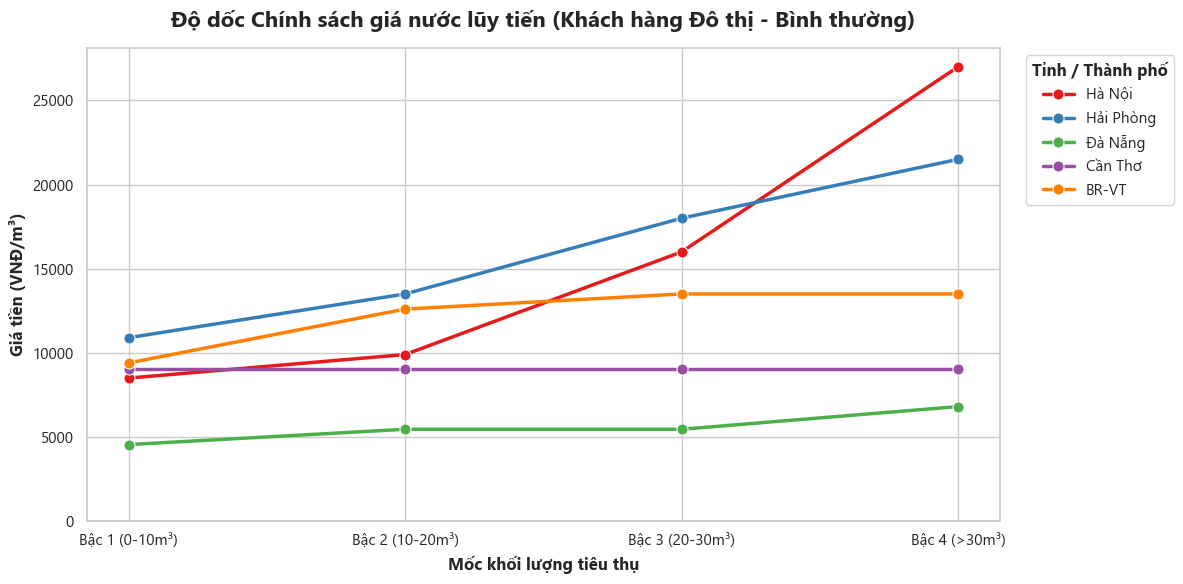

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập font tiếng Việt và style
plt.rcParams['font.family'] = 'Segoe UI'
sns.set_theme(style="whitegrid", font="Segoe UI")

# Đọc dữ liệu sạch từ file CSV
df_baseline = pd.read_csv('Dataset 1/baseline_hocu_dothi.csv')

# Khởi tạo biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ Line Chart với điểm nhấn là tham số marker='o'
sns.lineplot(
    data=df_baseline,
    x='Bac_Tieu_Thu',
    y='Gia_Tien',
    hue='Tinh_Thanh',
    marker='o',          # Đánh dấu các mốc chuyển bậc bằng dấu chấm tròn
    markersize=8,        # Tăng kích thước chấm tròn cho rõ nét
    linewidth=2.5,       # Làm đồ thị nét và đậm hơn
    palette='Set1'       # Dải màu tương phản mạnh để dễ phân biệt 5 tỉnh
)

# Trang trí biểu đồ
plt.title('Độ dốc Chính sách giá nước lũy tiến (Khách hàng Đô thị - Bình thường)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Mốc khối lượng tiêu thụ', fontsize=12, fontweight='bold')
plt.ylabel('Giá tiền (VNĐ/m³)', fontsize=12, fontweight='bold')

# Đẩy bảng chú thích ra ngoài khung hình để không che mất đường biểu đồ
plt.legend(title='Tỉnh / Thành phố', bbox_to_anchor=(1.02, 1), loc='upper left', title_fontproperties={'weight':'bold'})
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Trực quan hóa Dataset 1: Khoảng cách An sinh xã hội (Dumbbell Chart)
- **Mục tiêu:** Đo lường mức độ can thiệp và hỗ trợ của chính sách nhà nước đối với nhóm yếu thế nhất tại mốc tiêu thụ thiết yếu (0-10m³).
- **Kỹ thuật trực quan (Visual Encoding):** - Dùng biểu đồ tạ tay thẳng đứng (Vertical Dumbbell Chart) thay vì cột, giúp tiết kiệm không gian và nhấn mạnh trực tiếp vào "Khoảng cách" (Gap).
  - **Đầu trên (Màu đỏ):** Giá gốc của nhóm Tiêu chuẩn.
  - **Đầu dưới (Màu xanh):** Giá đã trợ cấp của nhóm Yếu thế.
  - **Độ dài cán tạ (Thanh xám):** Đại diện cho "Độ rộng của chính sách an sinh" – thanh càng dài, mức độ bù giá của tỉnh đó càng lớn.

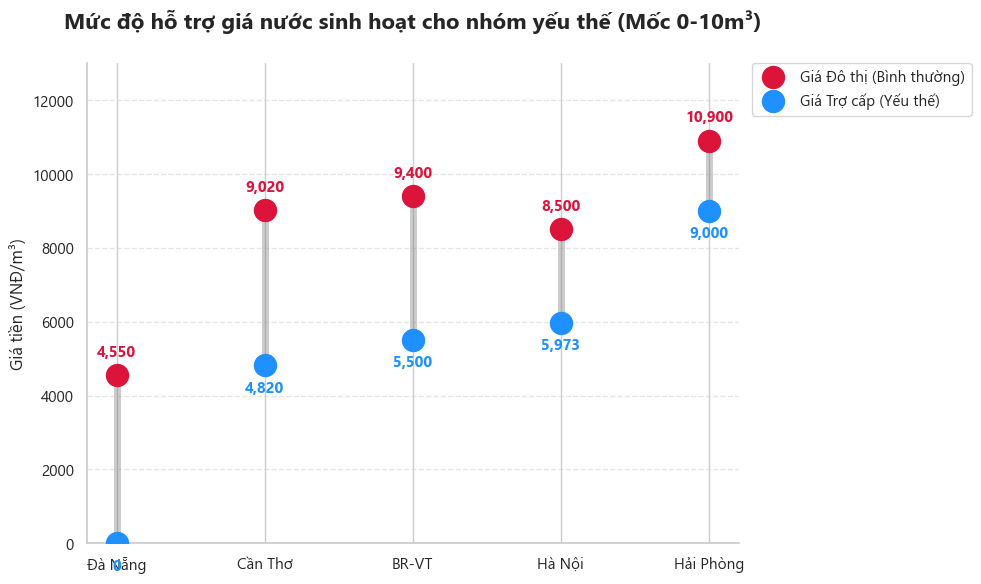

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập font tiếng Việt
plt.rcParams['font.family'] = 'Segoe UI'

# Đọc dữ liệu sạch từ file CSV
df_welfare = pd.read_csv('Dataset 1/welfare_ansinh_xh.csv')

# Khởi tạo biểu đồ
plt.figure(figsize=(10, 6))

# 1. Vẽ thanh dọc nối 2 điểm (Cán tạ)
plt.vlines(
    x=df_welfare['Tinh_Thanh'], 
    ymin=df_welfare['Gia_Tro_Cap'], 
    ymax=df_welfare['Gia_Binh_Thuong'], 
    color='grey', alpha=0.4, linewidth=5
)

# 2. Vẽ đầu trên (Giá bình thường - Điểm màu đỏ)
plt.scatter(
    x=df_welfare['Tinh_Thanh'], 
    y=df_welfare['Gia_Binh_Thuong'], 
    color='crimson', s=250, label='Giá Đô thị (Bình thường)', zorder=3
)

# 3. Vẽ đầu dưới (Giá trợ cấp - Điểm màu xanh)
plt.scatter(
    x=df_welfare['Tinh_Thanh'], 
    y=df_welfare['Gia_Tro_Cap'], 
    color='dodgerblue', s=250, label='Giá Trợ cấp (Yếu thế)', zorder=3
)

# 4. Vòng lặp gắn nhãn con số trực tiếp lên các điểm tạ để dễ đọc
for i, row in df_welfare.iterrows():
    # Nhãn cho giá bình thường (nằm sát trên điểm đỏ)
    plt.text(
        row['Tinh_Thanh'], row['Gia_Binh_Thuong'] + 400, 
        f"{row['Gia_Binh_Thuong']:,.0f}", 
        ha='center', va='bottom', fontsize=11, fontweight='bold', color='crimson'
    )
    # Nhãn cho giá trợ cấp (nằm sát dưới điểm xanh)
    plt.text(
        row['Tinh_Thanh'], row['Gia_Tro_Cap'] - 400, 
        f"{row['Gia_Tro_Cap']:,.0f}", 
        ha='center', va='top', fontsize=11, fontweight='bold', color='dodgerblue'
    )

# Trang trí biểu đồ
plt.title('Mức độ hỗ trợ giá nước sinh hoạt cho nhóm yếu thế (Mốc 0-10m³)', fontsize=16, fontweight='bold', pad=25)
plt.ylabel('Giá tiền (VNĐ/m³)', fontsize=12)
plt.ylim(0, 13000) # Ép khung trục Y xuống âm để tạo khoảng không cho giá 0đ của Đà Nẵng

# Thiết lập Legend và Grid
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Xóa viền khung trên và phải cho thanh thoát (Tư duy thiết kế Tufte)
sns.despine()

plt.tight_layout()
plt.show()